In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
## load dataset

df = pd.read_csv('/content/train.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [28]:
## dataset shape
df.shape

(1460, 81)

In [29]:
## display dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [30]:
## check missing values
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [31]:
## sepaarte numerical and categorical columns
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns

In [32]:
## fill missing numerical values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

df[num_cols] = imputer.fit_transform(df[num_cols])


In [33]:
## fill missing categorical values
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [34]:
## encode categorical values
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [35]:
## separate features and targets
X = df.drop('SalePrice', axis=1)

y = df['SalePrice']

In [36]:
## feature scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [37]:
## Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
## linear regression model
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [39]:
## Ridge regression model
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

In [40]:
## Lasso regression
from sklearn.linear_model import Lasso

lasso = Lasso()

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.539e+09, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


In [41]:
## Gradient boosting model
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

In [42]:
## Evaluate models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
## evaluating function
def evaluate_model(y_test, pred, model_name):

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    print(f"Model: {model_name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("----------------------")

In [44]:
## evaluate all models
evaluate_model(y_test, lr_pred, "Linear Regression")

evaluate_model(y_test, ridge_pred, "Ridge Regression")

evaluate_model(y_test, lasso_pred, "Lasso Regression")

evaluate_model(y_test, gbr_pred, "Gradient Boosting")

Model: Linear Regression
MAE: 21585.48149097958
MSE: 1248056960.516291
RMSE: 35327.84964466831
R2 Score: 0.8372876293909304
----------------------
Model: Ridge Regression
MAE: 21575.910988653486
MSE: 1247347865.9235137
RMSE: 35317.812303758474
R2 Score: 0.8373800758623872
----------------------
Model: Lasso Regression
MAE: 21583.110922499844
MSE: 1247918993.1210048
RMSE: 35325.896918847015
R2 Score: 0.8373056165523052
----------------------
Model: Gradient Boosting
MAE: 17022.707942266166
MSE: 804259729.5588697
RMSE: 28359.47336533014
R2 Score: 0.8951466068281065
----------------------


In [45]:
## Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4]
}

grid = GridSearchCV(
    GradientBoostingRegressor(),
    params,
    cv=3
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}


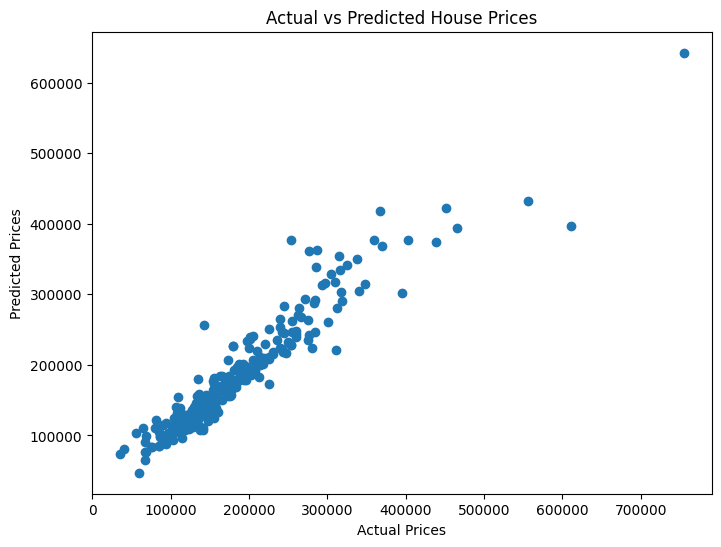

In [46]:
## Visualization

plt.figure(figsize=(8,6))

plt.scatter(y_test, gbr_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

CONCLUSION:

This project predicts house prices using machine learning regression models. After preprocessing and training multiple models, Gradient Boosting Regressor achieved the best accuracy and performance. The project shows the importance of data cleaning, feature engineering, and model evaluation in machine learning.

Hence,Project Completed Successfully....
